In [89]:
# Importation des packages

# Standard library imports
import os

# Third-party library imports
import joblib
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import random

# Scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Other machine learning library imports
from xgboost import XGBRegressor

# Statsmodels and Scipy imports for statistical tests
from scipy.stats import shapiro
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

from copy import deepcopy

In [90]:

random.seed(42)

# Facultatif : Si vous utilisez scikit-learn dans des modèles spécifiques
# la graine est souvent définie dans les paramètres du modèle (e.g., random_state=42)

print("Graine aléatoire globale définie à 42")

Graine aléatoire globale définie à 42


### **Importation**

In [91]:

# Télécharger le dataset
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Chemin du dossier :", path)

# Lister les fichiers
files = os.listdir(path)
print("Fichiers disponibles :", files)

# Charger le CSV
csv_path = os.path.join(path, "insurance.csv")
data = pd.read_csv(csv_path)

# Afficher les 10 premières lignes
display(data.head(10))


Using Colab cache for faster access to the 'insurance' dataset.
Chemin du dossier : /kaggle/input/insurance
Fichiers disponibles : ['insurance.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [92]:
display(data.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### **Preprocessing**

#### **Suppression des doublons**

In [93]:
print(f"Dimensions du dataset avant suppression des doublons : {data.shape}")

data.drop_duplicates(inplace=True)

print(f"Dimensions du dataset après suppression des doublons : {data.shape}")

Dimensions du dataset avant suppression des doublons : (1338, 7)
Dimensions du dataset après suppression des doublons : (1337, 7)


#### **Transformation logarithmique de la variable cible**

In [94]:
import numpy as np

# Applique une transformation logarithmique à la variable cible 'charges'
# np.log1p est utilisé car il gère mieux les valeurs nulles que np.log()
data['charges'] = np.log1p(data['charges'])

In [95]:
display(data.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,9.734236
1,18,male,33.770,1,no,southeast,7.453882
2,28,male,33.000,3,no,southeast,8.400763
3,33,male,22.705,0,no,northwest,9.998137
4,32,male,28.880,0,no,northwest,8.260455


### **Processing**

Ici, nous séparons les variables catégorielles des variables quantitative continue.

L'idée est de pouvoir appliquer le traitement de façon séparé : `Mise en echelle pour les variables age et bmi` et `encoding pour les variables sex, smoker et region`

In [96]:
# Définition des groupes de colonnes
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']

In [97]:
# Pipeline pour les chiffres : Mise à l'échelle (Place réservée)
num_transformer = Pipeline(steps=[
    ('scaler', 'passthrough')
])

# Pipeline pour les catégories : Encodage
# On utilise drop='first' pour éviter le piège des variables factices
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])


# Assemblage du Preprocessor
preprocessor_template = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

### **Séparation des données**

In [98]:
## Séparation en variables explicatives et variable cible
X = data.drop('charges', axis=1)
y = data['charges']

## Séparation en donnée d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


### **Modélisation**

#### ***Définition des scalers***

In [99]:
# On définit les scalers à tester pour les modèles sensibles
scalers = {
        'None': 'passthrough',
        'Standard': StandardScaler(),
        'MinMax': MinMaxScaler(),
        'Robust': RobustScaler(),
        'MaxAbs': MaxAbsScaler()
    }

#### ***Définition des modèles***

In [100]:
# --- GROUPE 1 : MODÈLES NON-ENSEMBLISTES (Simple/Baseline) ---
non_ensemble_scaling = {
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet(),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR()
}

non_ensemble_no_scaling = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor()
}

# --- GROUPE 2 : MODÈLES ENSEMBLISTES (Puissance) ---
ensemble_models = {
    'RandomForest': RandomForestRegressor(),
    'GradientBoost': GradientBoostingRegressor(),
    'XGBoost': XGBRegressor()
}

#### ***Définition des fonctions***

In [101]:
# Fonction qui entrainera tous les modèles et affichée les métriques
def evaluate_pipeline(X_train, X_test, y_train, y_test, preprocessor, model_name, model_obj, scaler_name,encoder_name):
    """Fonction utilitaire pour entraîner et calculer les métriques"""
    pipe = Pipeline(steps=[('prepro', preprocessor), ('reg', model_obj)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    res = {
        'Model': model_name,
        'Scaler': scaler_name,
        'Encoder': encoder_name,
        'MAE_Train': mean_absolute_error(y_train, y_train_pred),
        'MAE_Test': mean_absolute_error(y_test, y_test_pred),
        'MSE_Train': mean_squared_error(y_train, y_train_pred),
        'MSE_Test': mean_squared_error(y_test, y_test_pred),
        'RMSE_Train': root_mean_squared_error(y_train, y_train_pred),
        'RMSE_Test': root_mean_squared_error(y_test, y_test_pred),
        'MAPE_Train': mean_absolute_percentage_error(y_train, y_train_pred),
        'MAPE_Test': mean_absolute_percentage_error(y_test, y_test_pred),
        'R2_Train': r2_score(y_train, y_train_pred),
        'R2_Test': r2_score(y_test, y_test_pred)
    }
    res['Overfit_Diff'] = abs(res['R2_Train'] - res['R2_Test'])
    return res

In [102]:
#
def train_multiple_models(X_train, X_test, y_train, y_test, scalers, models_dict, preprocessor_template, force_scaling=True, force_encoding="drop"):
    results = []

    # Create a fresh copy of the preprocessor template for each run
    # This prevents side effects across different calls to train_multiple_models
    # and ensures the base preprocessor_encode defined globally remains untouched.
    preprocessor = deepcopy(preprocessor_template)

    # --- Configure Encoding ---
    # The categorical transformer is at index 1 in the ColumnTransformer's transformers list
    # Its pipeline is the second element (index 1) of that tuple
    # The 'onehot' step is the first step (index 0) in that pipeline's steps list
    if  force_encoding =="None":
        preprocessor.transformers[1][1].steps[0] = ('onehot', 'passthrough')
        encoder_name = 'No Encoding'
    if force_encoding == "all":
        preprocessor.transformers[1][1].steps[0] = ('onehot', OneHotEncoder(handle_unknown='ignore'))
        encoder_name = 'OneHot Encoding with All'
    else:
        # Default is OneHotEncoder, so we don't need to change it if force_encoding is True
        encoder_name = 'OneHot Encoding with Drop'

    # --- Configure Scaling and Run Models ---
    # The numerical transformer is at index 0 in the ColumnTransformer's transformers list
    # Its pipeline is the second element (index 1) of that tuple
    # The 'scaler' step is the first step (index 0) in that pipeline's steps list
    if force_scaling:
        # On teste chaque scaler pour chaque modèle
        for scaler_name, scaler_obj in scalers.items():
            preprocessor.transformers[0][1].steps[0] = ('scaler', scaler_obj)
            scal_name = scaler_name if scaler_name != 'None' else 'No Scaling'
            # On teste chaque modèle
            for model_name, model_obj in models_dict.items():
                results.append(evaluate_pipeline(X_train, X_test, y_train, y_test, preprocessor, model_name, model_obj, scal_name,encoder_name))
    else:
        # Pas de scaling (Passthrough)
        preprocessor.transformers[0][1].steps[0] = ('scaler', 'passthrough')
        scal_name = 'No Scaling'
        for model_name, model_obj in models_dict.items():
            results.append(evaluate_pipeline(X_train, X_test, y_train, y_test, preprocessor, model_name, model_obj, scal_name,encoder_name))

    return pd.DataFrame(results)

In [103]:
###Afficher le tableau mieux styliser
def style_results(df):
    def highlight_issues(row):
        # Si l'écart de R2 est > 0.1, c'est probablement de l'overfitting (Rouge)
        color = 'background-color: #ffcccc' if row['Overfit_Diff'] > 0.1 else ''
        return [color] * len(row)

    styled = df.style.apply(highlight_issues, axis=1) \
        .highlight_min(subset=['MAE_Test'], color='lightgreen') \
        .highlight_min(subset=['MSE_Test'], color='lightgreen') \
        .highlight_min(subset=['RMSE_Test'], color='lightgreen') \
        .highlight_min(subset=['MAPE_Test'], color='lightgreen') \
        .highlight_max(subset=['R2_Test'], color='lightgreen') \
        .format(precision=2)

    return styled

#### ***Application des fonctions***

In [104]:
# Modèles Non-Ensemblistes ---
print("Entraînement des modèles Non-Ensemblistes...")
res_non_ensemble = pd.concat([
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, non_ensemble_scaling, preprocessor_template, force_scaling=True),
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, non_ensemble_no_scaling, preprocessor_template, force_scaling=False)
])

Entraînement des modèles Non-Ensemblistes...


In [105]:
# Modèles Ensemblistes ---
print("Entraînement des modèles Ensemblistes...")
# Pour les arbres/ensembles, on force le passthrough car le scaling n'apporte rien

res_ensemble = pd.concat([
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, ensemble_models, preprocessor_template, force_scaling=False,force_encoding="drop"),
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, ensemble_models, preprocessor_template, force_scaling=False,force_encoding="all")
])

Entraînement des modèles Ensemblistes...


In [106]:
combined_results = pd.concat([res_non_ensemble, res_ensemble], ignore_index=True)
style_results(combined_results)

,Model,Scaler,Encoder,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,MAPE_Train,MAPE_Test,R2_Train,R2_Test,Overfit_Diff
0,Lasso,No Scaling,OneHot Encoding with Drop,0.63,0.62,0.61,0.62,0.78,0.79,0.07,0.07,0.26,0.29,0.04
1,Ridge,No Scaling,OneHot Encoding with Drop,0.28,0.27,0.20,0.18,0.45,0.43,0.03,0.03,0.76,0.79,0.03
2,ElasticNet,No Scaling,OneHot Encoding with Drop,0.63,0.62,0.61,0.61,0.78,0.78,0.07,0.07,0.26,0.30,0.04
3,KNN,No Scaling,OneHot Encoding with Drop,0.45,0.53,0.38,0.56,0.62,0.75,0.05,0.06,0.54,0.36,0.18
4,SVR,No Scaling,OneHot Encoding with Drop,0.46,0.46,0.63,0.60,0.80,0.78,0.05,0.05,0.23,0.31,0.08
5,Lasso,Standard,OneHot Encoding with Drop,0.74,0.75,0.83,0.88,0.91,0.94,0.08,0.08,0.00,-0.00,0.00
6,Ridge,Standard,OneHot Encoding with Drop,0.28,0.27,0.20,0.18,0.45,0.43,0.03,0.03,0.76,0.79,0.03
7,ElasticNet,Standard,OneHot Encoding with Drop,0.74,0.75,0.83,0.88,0.91,0.94,0.08,0.08,0.00,-0.00,0.00
8,KNN,Standard,OneHot Encoding with Drop,0.25,0.31,0.16,0.24,0.40,0.49,0.03,0.03,0.81,0.72,0.08
9,SVR,Standard,OneHot Encoding with Drop,0.17,0.18,0.13,0.14,0.37,0.38,0.02,0.02,0.84,0.84,0.00


#### **Détail sur le modele de regression linéaire**

##### ***Entrainement et prédiction***

In [107]:

#Construction de la pipeline
Regression_lineaire = Pipeline(steps=[
    ('prepro', preprocessor_template),
    ('reg', LinearRegression())
])

# Entrainement
Regression_lineaire.fit(X_train, y_train)

Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   'passthrough')]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('reg', LinearRegression())])

In [108]:
y_pred_lr = Regression_lineaire.predict(X_test)
residuals_lr = y_test - y_pred_lr


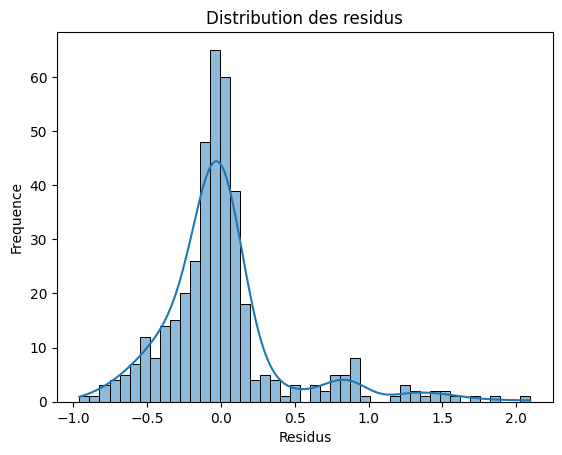

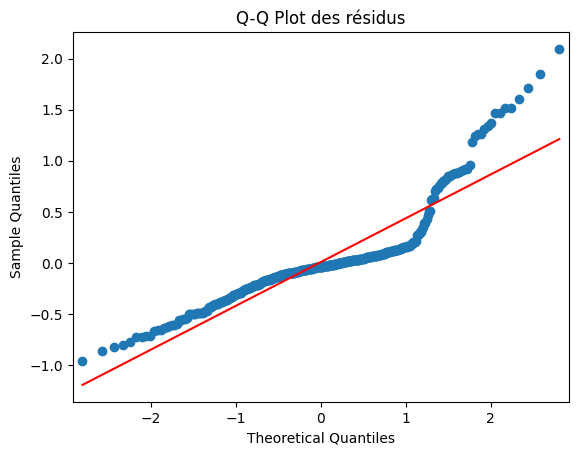

In [109]:
# Plotting the histogram of residuals
sns.histplot(residuals_lr, kde=True)
plt.title('Distribution des residus')
plt.xlabel('Residus')
plt.ylabel('Frequence')

# Plotting the Q-Q plot of residuals
sm.qqplot(residuals_lr, line='s')
plt.title('Q-Q Plot des résidus')
plt.show()

##### **Normalité des résidus**

In [110]:


# Perform Shapiro-Wilk test on the residuals
shapiro_test_statistic, shapiro_p_value = shapiro(residuals_lr)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test_statistic:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p_value:.4f}")

# Interpret the p-value
alpha = 0.05
if shapiro_p_value < alpha:
    print("Conclusion: Les résidus ne semble pas suivre une distribution normale (rejet H0).")
else:
    print("Conclusion: Les résidus semble suivre une distribution normale (non rejet de H0).")

Shapiro-Wilk Test Statistic: 0.8336
Shapiro-Wilk p-value: 0.0000
Conclusion: Les résidus ne semble pas suivre une distribution normale (rejet H0).


##### Homoscédasticité

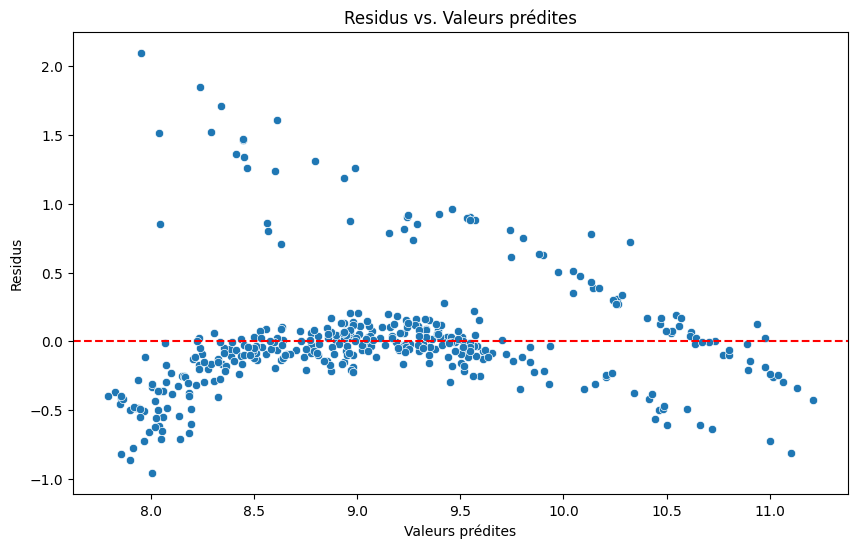

In [111]:


# Create a scatter plot of residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr, y=residuals_lr)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Valeurs prédites')
plt.ylabel('Residus')
plt.title('Residus vs. Valeurs prédites')
plt.show()

In [112]:

# 4. Apply the preprocessor to X_test
X_test_preprocessed = preprocessor_template.transform(X_test)

# 5. Add a constant term to the preprocessed X_test data
X_test_preprocessed_with_const = sm.add_constant(X_test_preprocessed)

# 6. Perform the Breusch-Pagan test
bp_test = het_breuschpagan(residuals_lr, X_test_preprocessed_with_const)

# Store the results in a dictionary for easy access and printing
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_results = dict(zip(labels, bp_test))

# 7. Print the results of the Breusch-Pagan test
print("Breusch-Pagan Test Results:")
for label, value in bp_results.items():
    print(f"{label}: {value:.4f}")

# 8. Interpret the p-value (F-Test p-value)
alpha = 0.05
if bp_results['F-Test p-value'] < alpha:
    print(f"\nConclusion: F-Test p-value ({bp_results['F-Test p-value']:.4f}) < alpha ({alpha}), donc nous rejetons H0.\nIl existe suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.")
else:
    print(f"\nConclusion: F-Test p-value ({bp_results['F-Test p-value']:.4f}) >= alpha ({alpha}), donc nous rejetons H0.\nIl n'existe pas suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.")

Breusch-Pagan Test Results:
LM Statistic: 30.6054
LM-Test p-value: 0.0002
F-Statistic: 4.0482
F-Test p-value: 0.0001

Conclusion: F-Test p-value (0.0001) < alpha (0.05), donc nous rejetons H0.
Il existe suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.


##### ***Indépendance des résidus***

In [113]:

# Perform the Durbin-Watson test on the residuals
dw_test = durbin_watson(residuals_lr)

# Print the Durbin-Watson test statistic
print(f"Durbin-Watson test statistic: {dw_test:.4f}")

# Interpret the Durbin-Watson statistic
if dw_test < 1.5 or dw_test > 2.5:
    print("Conclusion: The residuals exhibit evidence of autocorrelation (not independent).")
else:
    print("Conclusion: The residuals appear to be independent (no significant autocorrelation).")

Durbin-Watson test statistic: 1.8119
Conclusion: The residuals appear to be independent (no significant autocorrelation).


### **Optimisation des hyperparamètres**

In [114]:
# --- GROUPE 1 : MODÈLES NON-ENSEMBLISTES (Simple/Baseline) ---
non_ensemble_scaling = {
    'Lasso': (Lasso(max_iter=10000), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0]
        }),
        'Ridge': (Ridge(), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0]
        }),
        'ElasticNet': (ElasticNet(), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0],
            'reg__l1_ratio': [0.0, 0.1, 0.5, 0.9]
        }),
        'KNN': (KNeighborsRegressor(), {
            'reg__n_neighbors': [3, 5, 7, 9],
            'reg__weights': ['uniform', 'distance']
        }),
        'SVR': (SVR(), {
            'reg__C': [0.1, 1, 10, 100],
            'reg__epsilon': [0.1, 0.2, 0.5, 1.0],
            'reg__kernel': ['rbf']
        })
}

non_ensemble_no_scaling = {
    'LinearRegression': (LinearRegression(), {
            'reg__fit_intercept': [True, False]
        }),

        'DecisionTree': (DecisionTreeRegressor(), {
            'reg__max_depth': [None, 5, 10, 15],
            'reg__min_samples_split': [2, 5, 10, 20]
        }),
}

# --- GROUPE 2 : MODÈLES ENSEMBLISTES (Puissance) ---
ensemble_models = {
    'RandomForest': (RandomForestRegressor(), {
            'reg__n_estimators': [50, 100, 200, 300],
            'reg__max_depth': [None, 10, 20, 30],
            'reg__min_samples_split': [2, 5, 10, 20]
        }),
        'XGBoost': (XGBRegressor(), {
            'reg__n_estimators': [50, 100, 200, 300],
            'reg__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'reg__max_depth': [3, 6, 9, 12]
        }),
        'GradientBoost': (GradientBoostingRegressor(), {
            'reg__n_estimators': [50, 100, 200, 300],
            'reg__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'reg__subsample': [0.6, 0.8, 0.9, 1.0]
        })
}

In [115]:

# Définir les différentes stratégies d'encodage

encoder_non_assembliste = {
    'OneHot_DropFirst': OneHotEncoder(handle_unknown='ignore', drop='first'),

}

encoder_assembliste = {
    'OneHot_DropFirst': OneHotEncoder(handle_unknown='ignore', drop='first'),
    'OneHot_KeepAll': OneHotEncoder(handle_unknown='ignore')
}

In [116]:
# Fonction pour gérer l'optimisation
def optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, models_to_tune, scalers, encoder_configs, metric_score):
    all_tuned_results = []
    best_estimators_per_config = {}

    # Si l'utilisateur passe 'None' au lieu d'un dictionnaire, on normalise en dictionnaire passthrough
    if scalers == 'None' or scalers is None:
        scalers_dict = {'No_Scaling': 'passthrough'}
    else:
        scalers_dict = scalers

    for scaler_name, scaler_obj in scalers_dict.items():
        for encoder_name, encoder_obj in encoder_configs.items():

            print(f"--- Tuning with Scaler: {scaler_name}, Encoder: {encoder_name} ---")

            # 1. Préparation du Numerical Transformer
            if scaler_obj == 'passthrough':
                num_transformer = 'passthrough'
            else:
                num_transformer = Pipeline(steps=[('scaler', scaler_obj)])

            # 2. Préparation du Categorical Transformer
            if encoder_obj == 'passthrough':
                cat_transformer = 'passthrough'
            else:
                cat_transformer = Pipeline(steps=[('onehot', encoder_obj)])

            # 3. Construction du ColumnTransformer
            transformers_list = []
            if num_features:
                transformers_list.append(('num', num_transformer, num_features))
            if cat_features:
                transformers_list.append(('cat', cat_transformer, cat_features))

            # Création du preprocessor (passthrough global si pas de features)
            current_preprocessor = ColumnTransformer(transformers_list) if transformers_list else 'passthrough'

            # 4. Boucle sur les modèles
            for name, (model, params) in models_to_tune.items():
                print(f"Optimisation de {name}...")

                # Création de la pipeline
                if current_preprocessor == 'passthrough':
                    pipe = Pipeline(steps=[('reg', model)])
                else:
                    pipe = Pipeline(steps=[('prepro', current_preprocessor), ('reg', model)])

                # Exécution du GridSearch
                grid = GridSearchCV(pipe, params, cv=5, scoring=metric_score, n_jobs=-1)
                grid.fit(X_train, y_train)

                # Sauvegarde du meilleur modèle entraîné
                config_key = f"{name}_{scaler_name}_{encoder_name}"
                best_model = grid.best_estimator_
                best_estimators_per_config[config_key] = best_model

                # Prédictions et Calcul des scores
                y_train_pred = best_model.predict(X_train)
                y_test_pred = best_model.predict(X_test)

                r2_tr, r2_te = r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)

                res = {
                    'Model': name,
                    'Scaler': scaler_name,
                    'Encoder': encoder_name,
                    'Best_MAE_CV': -grid.best_score_ if 'neg_' in metric_score else grid.best_score_,
                    'MAE_Train': mean_absolute_error(y_train, y_train_pred),
                    'MAE_Test': mean_absolute_error(y_test, y_test_pred),
                    'MSE_Train': mean_squared_error(y_train, y_train_pred),
                    'MSE_Test': mean_squared_error(y_test, y_test_pred),
                    'RMSE_Train': root_mean_squared_error(y_train, y_train_pred),
                    'RMSE_Test': root_mean_squared_error(y_test, y_test_pred),
                    'MAPE_Train': mean_absolute_percentage_error(y_train, y_train_pred),
                    'MAPE_Test': mean_absolute_percentage_error(y_test, y_test_pred),
                    'R2_Train': r2_tr,
                    'R2_Test': r2_te,
                    'Overfit_Diff': abs(r2_tr - r2_te),
                    'Best_Params': str(grid.best_params_)
                }
                all_tuned_results.append(res)

    return pd.DataFrame(all_tuned_results), best_estimators_per_config

In [ ]:
df_tuning, best_models_dict = optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, non_ensemble_scaling, scalers, encoder_non_assembliste, 'neg_mean_absolute_error')

--- Tuning with Scaler: None, Encoder: OneHot_DropFirst ---
Optimisation de Lasso...


In [ ]:
#style_results(df_tuning)

In [ ]:
df_tuning2, best_models_dict2 = optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, non_ensemble_no_scaling,'None', encoder_non_assembliste, 'neg_mean_absolute_error')

In [ ]:
#style_results(df_tuning2)

In [ ]:
df_tuning3, best_models_dict3 = optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, ensemble_models, 'None', encoder_assembliste, 'neg_mean_absolute_error')

In [ ]:
#style_results(df_tuning3)

In [ ]:
results = pd.concat([df_tuning, df_tuning2, df_tuning3],ignore_index=True)
style_results(results)

### **Choix du meilleur modèle**

#### ***Infos sur le meilleur modèle***

In [ ]:
best_model_idx = results['RMSE_Test'].idxmin()
best_model = results.loc[best_model_idx]
display(best_model)

In [ ]:
# Nom et paramètres du meilleur modèle
best_model_name = model_key = f"{best_model['Model']}_{best_model['Scaler']}_{best_model['Encoder']}"
best_params = best_model['Best_Params']

print(f"Meilleur modèle: {best_model_name}")
print(f"Hyperparamètres optimaux: {best_params}")

In [ ]:
#Pipeline du meilleur modèle
best_pipeline = best_models_dict3[best_model_name]

print(f"Objet pipeline du meilleur modèle: {best_pipeline}")


#### ***Prediction***


In [ ]:
##Prediction sur les données test
y_test_pred_final = best_pipeline.predict(X_test)

In [ ]:
## Calcul
# Calcul de l'erreur absolue moyenne (Mean Absolute Error - MAE) sur l'ensemble de test
mae_test_final = mean_absolute_error(y_test, y_test_pred_final)
# Calcul de l'erreur quadratique moyenne (Mean Squared Error - MSE) sur l'ensemble de test
mse_test_final = mean_squared_error(y_test, y_test_pred_final)
# Calcul de la racine carrée de l'erreur quadratique moyenne (Root Mean Squared Error - RMSE) sur l'ensemble de test
rmse_test_final = root_mean_squared_error(y_test, y_test_pred_final)
# Calcul de l'erreur absolue moyenne en pourcentage (Mean Absolute Percentage Error - MAPE) sur l'ensemble de test
mape_test_final = mean_absolute_percentage_error(y_test, y_test_pred_final)
# Calcul du coefficient de détermination (R2 score) sur l'ensemble de test
r2_test_final = r2_score(y_test, y_test_pred_final)


print("Metrique sur les prédictions")
print(f"MAE: {mae_test_final:.2f}")
print(f"MSE: {mse_test_final:.2f}")
print(f"RMSE: {rmse_test_final:.2f}")
print(f"MAPE: {mape_test_final:.2f}")
print(f"R2: {r2_test_final:.2f}")

In [ ]:
# Define a custom Pipeline class that applies np.expm1 to its predictions
class Expm1PredictionPipeline(Pipeline):
    """
    A Pipeline subclass that applies np.expm1 to the final predictions
    of the underlying regressor in the pipeline.
    """
    def predict(self, X, **predict_params):
        # Call the parent Pipeline's predict method to get log-transformed predictions
        log_predictions = super().predict(X, **predict_params)
        # Apply the inverse transformation (np.expm1)
        return np.expm1(log_predictions)

# Get the original steps and their *fitted estimators* from the best_pipeline.
# This is crucial because best_pipeline is already trained.
original_fitted_steps = []
for name, estimator in best_pipeline.steps:
    # We use named_steps to get the actual fitted estimator instance
    original_fitted_steps.append((name, best_pipeline.named_steps[name]))

# Recreate the best_pipeline as an instance of our custom class.
# This new pipeline will use the already fitted estimators from the original pipeline,
# and its predict method will now include the np.expm1 transformation.
best_pipeline = Expm1PredictionPipeline(original_fitted_steps)

print("La best_pipeline a été modifiée pour appliquer np.expm1 à ses prédictions.")
print(f"Type de la best_pipeline : {type(best_pipeline)}")

#### ***Simulation***

In [ ]:
# Création d'une nouvelle instance de données sous forme de DataFrame pour la simulation
# Chaque clé représente un nom de colonne et la valeur est une liste contenant la donnée correspondante
new_data_instance = pd.DataFrame({
    'age': [31, 60],         # Âge de la personne
    'sex': ['male','male'],       # Sexe de la personne
    'bmi': [25.0, 20.9],         # Indice de masse corporelle (IMC)
    'children': [1,3],       # Nombre d'enfants
    'smoker': ['yes','no'],      # Indicateur si la personne est fumeuse ou non
    'region': ['southwest','northeast'] # Région d'habitation de la personne
})

# Utilisation du pipeline du meilleur modèle (best_pipeline) pour prédire les charges
# pour la nouvelle instance de données. La méthode .predict() retourne un tableau.
predicted_charge = best_pipeline.predict(new_data_instance)

# Affichage de la prédiction des charges, formatée à deux décimales
# Nous accédons au premier élément du tableau 'predicted_charge' car la prédiction est pour une seule instance.
print(f"Prediction de charges pour la nouvelle donnée: {predicted_charge}")

#### ***Importance relative des variables***

In [ ]:

# Get the feature importances from the regressor in the pipeline
regressor = best_pipeline.named_steps['reg']
feature_importances = regressor.feature_importances_

# Get feature names after preprocessing from the fitted ColumnTransformer
fitted_preprocessor = best_pipeline.named_steps['prepro']
all_feature_names = fitted_preprocessor.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})


In [ ]:
 # Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

display(feature_importance_df)

In [ ]:
# Plot feature importances
plt.figure(figsize=(12, 7)) # Increased figure size for better vertical display
sns.barplot(x='Feature', y='Importance', data=feature_importance_df)
plt.title('Importance des variables')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### ***Sauvegarde de la pipeline***

In [ ]:


# Choose a relevant file name
model_filename = 'best_gradient_boost_model.joblib'

# Save the best_pipeline
joblib.dump(best_pipeline, model_filename)

print(f"Le meilleur modèle a été sauvegardé sous le nom: {model_filename}")

### **Utilisation de la sauvegarde**

In [ ]:

# Définit le nom du fichier où le meilleur modèle a été sauvegardé précédemment
model_filename = 'best_gradient_boost_model.joblib'

# Charge le modèle (pipeline complet) depuis le fichier spécifié en utilisant joblib.load()
loaded_pipeline = joblib.load(model_filename)
# Affiche un message confirmant que le modèle a été chargé avec succès
print(f"Le modèle a été chargé depuis {model_filename}")

# Crée un nouveau DataFrame pour une instance de données 'inconnue' sur laquelle nous voulons faire une prédiction.
# Il est essentiel que les noms et l'ordre des colonnes, ainsi que leurs types de données, correspondent à ceux utilisés lors de l'entraînement du modèle.
new_unseen_data = pd.DataFrame({
    'age': [40],         # Âge de la personne (valeur numérique)
    'sex': ['female'],     # Sexe de la personne (catégorie)
    'bmi': [28.5],         # Indice de masse corporelle (IMC) (valeur numérique)
    'children': [2],       # Nombre d'enfants (valeur numérique)
    'smoker': ['no'],      # Indicateur si la personne est fumeuse ou non (catégorie)
    'region': ['northwest'] # Région d'habitation de la personne (catégorie)
})

# Utilise le pipeline chargé ('loaded_pipeline') pour prédire les charges pour la nouvelle instance de données.
# La méthode .predict() applique automatiquement toutes les étapes de prétraitement (scaling, encodage) avant la prédiction par le modèle sous-jacent.
predicted_charge_loaded_model = loaded_pipeline.predict(new_unseen_data)

# Affiche le résultat de la prédiction.
# predicted_charge_loaded_model est un tableau NumPy, nous accédons au premier (et unique) élément [0]
# et le formatons pour afficher deux chiffres après la virgule pour plus de clarté.
print(f"Prédiction des charges pour la nouvelle donnée en utilisant le modèle chargé : {predicted_charge_loaded_model[0]:.2f}")